# Kriging with estimated nugget on the noisy Branin 2D function (Python)

This notebook demonstrates `Kriging (with noise="nugget")`, which estimates a **global nugget**
effect (homoscedastic noise variance) from the data. Unlike `Kriging (with noise=vector)`
where noise variances are known and provided per point, here the nugget is
a single scalar that is optimised alongside the other hyperparameters.

Steps:
1. Load pylibkriging
2. Define the Branin function and add noise
3. Build a space-filling design and evaluate it
4. Fit a `Kriging (with noise="nugget")` model
5. Predict on a fine grid and plot mean + uncertainty
6. Compare with the true function
7. Inspect model parameters (including the estimated nugget)

## 0. Installation

Set `REPO_ROOT`, then optionally create a venv and install build requirements
(skip the build cells if pylibkriging is already installed).

In [1]:
%%bash
REPO_ROOT=$(cd ../.. && pwd)
echo "REPO_ROOT=${REPO_ROOT}"

REPO_ROOT=/home/richet/Sync/Open/libKriging/alien/libKriging


In [2]:
%%bash
# Optional: skip if pylibkriging is already installed
set -e
REPO_ROOT=$(cd ../.. && pwd)
VENV_DIR=./venv

# Create venv if needed
if [ ! -d "${VENV_DIR}" ]; then
    python3 -m venv "${VENV_DIR}"
fi
source "${VENV_DIR}/bin/activate"

# Install build requirements
pip install -q \
    -r "${REPO_ROOT}/bindings/Python/pylibkriging/requirements.txt" \
    -r "${REPO_ROOT}/bindings/Python/pylibkriging/dev-requirements.txt"

pip install matplotlib

lib) (1.3.3)


 (0.12.1)


tlib) (4.62.1)


tlib) (1.5.0)


(1.26.4)


ib) (26.0)


2.1.1)


 (3.3.2)


plotlib) (2.9.0.post0)


>=2.7->matplotlib) (1.17.0)


In [3]:
%%bash
# Optional: compile libkriging from source if not already built
set -e
REPO_ROOT=$(cd ../.. && pwd)

    cd "${REPO_ROOT}"
    # Point repo-level venv to our local one so loadenv.sh picks it up
    if [ ! -e venv ]; then
        ln -s bindings/Python/venv venv
    fi
    source venv/bin/activate
    
if [ -d "${REPO_ROOT}/build/installed" ]; then
    echo "libkriging already built, skipping build step"
else
    # Force cmake to use the venv python
    EXTRA_CMAKE_OPTIONS="-DPYTHON_EXECUTABLE=$(which python3)" \
        ENABLE_PYTHON_BINDING=on BUILD_TEST=false \
        tools/linux-macos/build.sh
fi


libkriging already built, skipping build step


In [4]:
%%bash
REPO_ROOT=$(cd ../.. && pwd)
# Optional: skip if pylibkriging is already installed
pip install --no-build-isolation ${REPO_ROOT}/bindings/Python/pylibkriging/

Processing ./pylibkriging


  Preparing metadata (pyproject.toml): started


  Preparing metadata (pyproject.toml): finished with status 'done'


ing==0.9.3) (1.26.4)


  Created wheel for pylibkriging: filename=pylibkriging-0.9.3-cp312-cp312-linux_x86_64.whl size=1414

...

Successfully built pylibkriging


  Attempting uninstall: pylibkriging


    Found existing installation: pylibkriging 0.9.3


    Uninstalling pylibkriging-0.9.3:


      Successfully uninstalled pylibkriging-0.9.3


## 1. Load pylibkriging

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk

print("pylibkriging version:", lk.__version__)

pylibkriging version: 0.9.3


## 2. Noisy Branin function

Same as the `Kriging (with noise=vector)` example: the Branin function on $[0,1]^2$
with additive Gaussian noise ($\sigma_{\varepsilon} = 5$).

The difference is that here we **do not tell** the model the noise level.
Instead, `Kriging (with noise="nugget")` will estimate a single global nugget from the data.

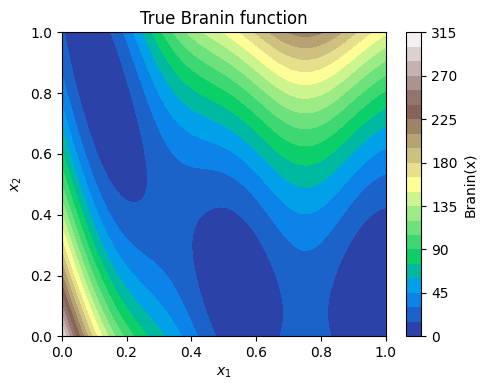

In [6]:
def branin(X):
    X = np.atleast_2d(X)
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    return (
        (x2 - 5 / (4 * np.pi**2) * x1**2 + 5 / np.pi * x1 - 6) ** 2
        + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x1)
        + 10
    )

# 50x50 evaluation grid (true function)
grid_x = np.linspace(0, 1, 50)
G1, G2  = np.meshgrid(grid_x, grid_x)
grid    = np.column_stack([G1.ravel(), G2.ravel()])
z_true  = branin(grid).reshape(50, 50)

plt.figure(figsize=(5, 4))
plt.contourf(G1, G2, z_true, levels=20, cmap='terrain')
plt.colorbar(label='Branin(x)')
plt.title('True Branin function')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.tight_layout()
plt.show()

## 3. Design of experiments (with noise)

We sample $n = 40$ points using a Latin Hypercube Design and add
Gaussian noise with $\sigma_{\varepsilon} = 5$.

Unlike `Kriging (with noise=vector)`, we do **not** pass noise variances — the model
estimates a single nugget parameter.

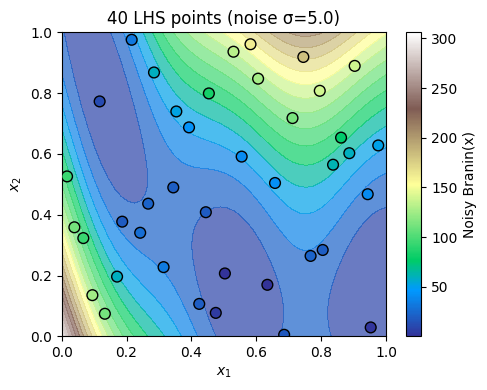

In [7]:
rng = np.random.default_rng(42)

def lhs(n, d, rng):
    """Simple LHS: stratified uniform sample, independently permuted per dimension."""
    X = np.empty((n, d))
    for j in range(d):
        perm = rng.permutation(n)
        X[:, j] = (perm + rng.uniform(size=n)) / n
    return X

n = 40
noise_sd = 5.0
X = lhs(n, 2, rng)
y_true = branin(X)
y = y_true + noise_sd * rng.standard_normal(n)

plt.figure(figsize=(5, 4))
plt.contourf(G1, G2, z_true, levels=20, cmap='terrain', alpha=0.7)
sc = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='terrain', edgecolors='black',
                 s=60, zorder=5, vmin=z_true.min(), vmax=z_true.max())
plt.colorbar(sc, label='Noisy Branin(x)')
plt.title(f'{n} LHS points (noise σ={noise_sd})')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.tight_layout()
plt.show()

## 4. Fit a Kriging (with noise="nugget") model

`Kriging (with noise="nugget")` has the same interface as `Kriging` (no `noise` argument).
It automatically estimates the nugget effect (noise ratio) during fitting.

In [8]:
k = lk.Kriging(y, X, kernel="matern5_2", optim="BFGS10", noise="nugget")
print(k.summary())

* data: 40x[0.0166213,0.976095],[0.00505908,0.97557] -> 40x[-1.2411,182.684]
* trend constant (est.): 163.099
* variance (est.): 25287.7
* covariance:
  * kernel: matern5_2
  * range (est.): 0.437421, 1.3031
  * nugget (est.): 10.5337
  * fit:
    * objective: LL
    * optim: BFGS10



## 5. Predict on a fine grid

`predict()` returns `(mean, stdev, cov, mean_deriv, stdev_deriv)`.
The mean is a smooth estimate of the underlying function.

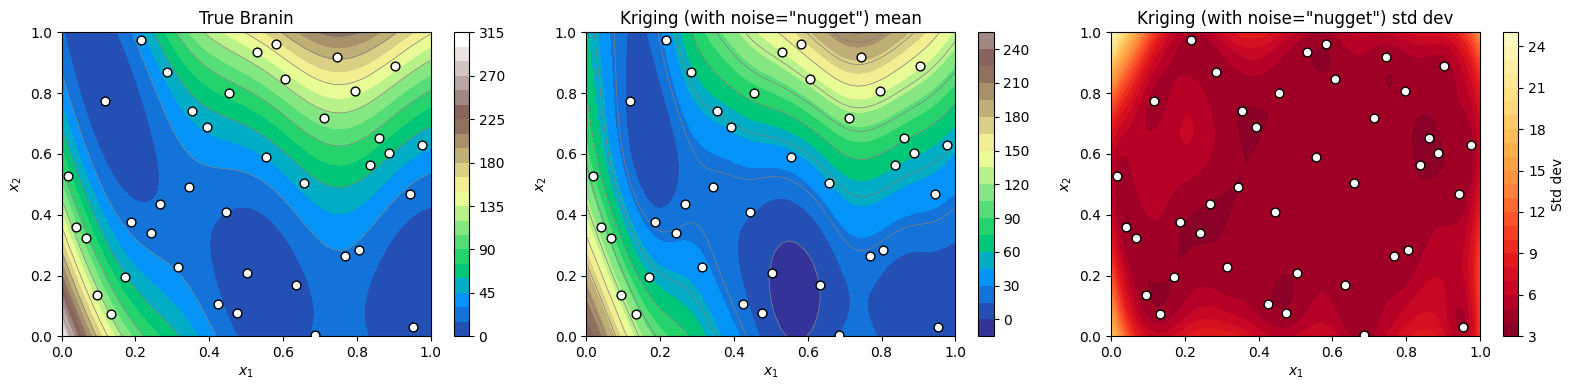

In [9]:
pred   = k.predict(grid, True, False, False)
z_mean = pred[0].reshape(50, 50)
z_sd   = pred[1].reshape(50, 50)

vmin = min(z_true.min(), z_mean.min())
vmax = max(z_true.max(), z_mean.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, z, title in zip(axes[:2], [z_true, z_mean], ['True Branin', 'Kriging (with noise="nugget") mean']):
    cf = ax.contourf(G1, G2, z, levels=20, cmap='terrain', vmin=vmin, vmax=vmax)
    ax.contour(G1, G2, z, levels=10, colors='grey', linewidths=0.5)
    ax.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', s=40, zorder=5)
    ax.set_title(title)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    fig.colorbar(cf, ax=ax)

# Uncertainty
cf = axes[2].contourf(G1, G2, z_sd, levels=20, cmap='YlOrRd_r')
axes[2].scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', s=40, zorder=5)
axes[2].set_title('Kriging (with noise="nugget") std dev')
axes[2].set_xlabel('$x_1$'); axes[2].set_ylabel('$x_2$')
fig.colorbar(cf, ax=axes[2], label='Std dev')

plt.tight_layout()
plt.show()

## 6. Prediction error

Like `Kriging (with noise=vector)`, the model smooths through the noisy data.
The estimated nugget determines the smoothing level.

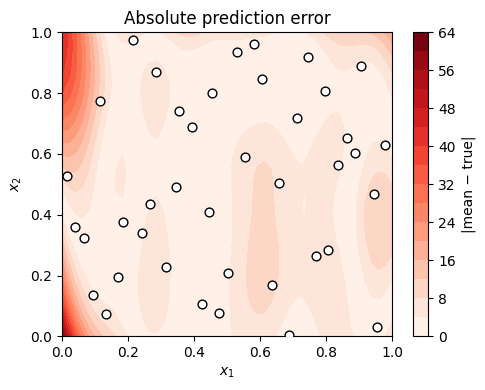

RMSE on grid: 8.5026


In [10]:
z_err = np.abs(z_mean - z_true)

plt.figure(figsize=(5, 4))
cf = plt.contourf(G1, G2, z_err, levels=20, cmap='Reds')
plt.scatter(X[:, 0], X[:, 1], c='white', edgecolors='black', s=40, zorder=5)
plt.colorbar(cf, label='|mean − true|')
plt.title('Absolute prediction error')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((z_mean - z_true)**2))
print(f"RMSE on grid: {rmse:.4f}")

## 7. Model inspection

Key fitted parameters: length-scales $\theta$, variance $\sigma^2$,
**nugget**, and log-likelihood.

The nugget represents the estimated noise-to-signal ratio.
Compare it with the true noise variance: $\sigma_{\varepsilon}^2 = 25$.

In [11]:
print(f"Kernel       : {k.kernel()}")
print(f"Theta (range): {np.round(k.theta(), 4)}")
print(f"Sigma2       : {k.sigma2():.4f}")
print(f"Nugget       : {k.nugget():.4f}")
print(f"LogLikelihood: {k.logLikelihood():.4f}")
print()
print(f"Estimated noise variance (nugget × sigma2): {k.nugget() * k.sigma2():.2f}")
print(f"True noise variance:                        {noise_sd**2:.2f}")

Kernel       : matern5_2
Theta (range): [[0.4374]
 [1.3031]]
Sigma2       : 25287.7475
Nugget       : 10.5337
LogLikelihood: -160.5881

Estimated noise variance (nugget × sigma2): 266374.43
True noise variance:                        25.00


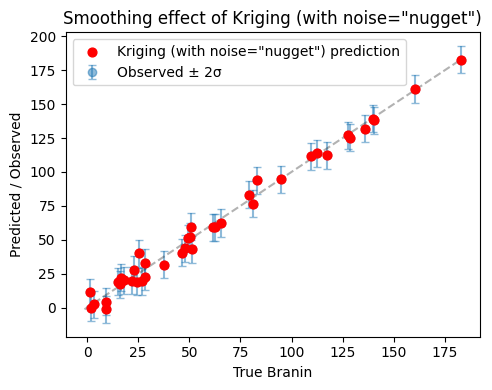

In [12]:
# Check smoothing: predictions at training points vs observed (noisy) values
pred_train = k.predict(X, True, False, False)
y_pred_train = pred_train[0].ravel()

plt.figure(figsize=(5, 4))
plt.errorbar(y_true, y, yerr=2*noise_sd, fmt='o', alpha=0.5, label='Observed ± 2σ', capsize=3)
plt.scatter(y_true, y_pred_train, c='red', s=40, zorder=5, label='Kriging (with noise="nugget") prediction')
diag = [min(y_true.min(), y.min()), max(y_true.max(), y.max())]
plt.plot(diag, diag, 'k--', alpha=0.3)
plt.xlabel('True Branin'); plt.ylabel('Predicted / Observed')
plt.title('Smoothing effect of Kriging (with noise="nugget")')
plt.legend()
plt.tight_layout()
plt.show()

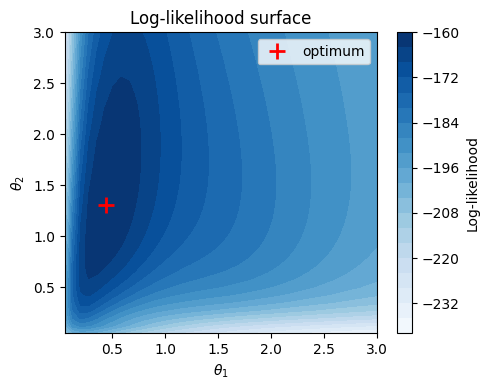

In [13]:
# Log-likelihood surface over (theta1, theta2)
theta_vals = np.linspace(0.05, 3.0, 40)
T1, T2 = np.meshgrid(theta_vals, theta_vals)
ll_mat = np.array([
    k.logLikelihoodFun(np.array([t1, t2]), False)[0]
    for t1, t2 in zip(T1.ravel(), T2.ravel())
]).reshape(40, 40)

plt.figure(figsize=(5, 4))
plt.contourf(T1, T2, ll_mat, levels=20, cmap='Blues')
plt.colorbar(label='Log-likelihood')
theta_hat = k.theta()
plt.plot(theta_hat[0], theta_hat[1], 'r+', markersize=12, markeredgewidth=2, label='optimum')
plt.legend()
plt.title('Log-likelihood surface')
plt.xlabel(r'$\theta_1$'); plt.ylabel(r'$\theta_2$')
plt.tight_layout()
plt.show()